# Exploratory Data Analysis
The goal is to look at revenue trends to get some insights into where it comes from and where to invest more resources and effort into.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import datetime as dt

In [2]:
df = pd.read_csv('data/online_retail_II_clean.csv',dtype={'Invoice':str})

In [3]:
df.dtypes

Invoice               str
StockCode             str
Description           str
Quantity            int64
InvoiceDate           str
Price             float64
Customer ID       float64
Country               str
Purchase Month        str
Revenue           float64
dtype: object

In [4]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df.dtypes

Invoice                      str
StockCode                    str
Description                  str
Quantity                   int64
InvoiceDate       datetime64[us]
Price                    float64
Customer ID              float64
Country                      str
Purchase Month               str
Revenue                  float64
dtype: object

In [5]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID,Revenue
count,1.041671e+06,1041671,1.041671e+06,805549.000000,1.041671e+06
mean,1.096345e+01,2011-01-03 16:31:26.403269,4.077038e+00,15331.954970,2.013397e+01
min,1.000000e+00,2009-12-01 07:45:00,1.000000e-03,12346.000000,1.000000e-03
25%,1.000000e+00,2010-07-12 10:26:00,1.250000e+00,13982.000000,3.900000e+00
50%,3.000000e+00,2010-12-07 15:33:00,2.100000e+00,15271.000000,9.960000e+00
75%,1.000000e+01,2011-07-24 12:05:00,4.130000e+00,16805.000000,1.770000e+01
max,8.099500e+04,2011-12-09 12:50:00,2.511109e+04,18287.000000,1.684696e+05
std,1.265149e+02,NaN,5.144898e+01,1696.737039,2.031167e+02


In [6]:
grouped = df.groupby('Purchase Month')['Revenue'].sum()
two_largest_revenues = grouped.nlargest(2)
highest_point = (two_largest_revenues.index[0], two_largest_revenues.iloc[0])
second_highest_point = (two_largest_revenues.index[1], two_largest_revenues.iloc[1])
highest_point, second_highest_point

(('2011-11', np.float64(1509496.33)), ('2010-11', np.float64(1470272.482)))

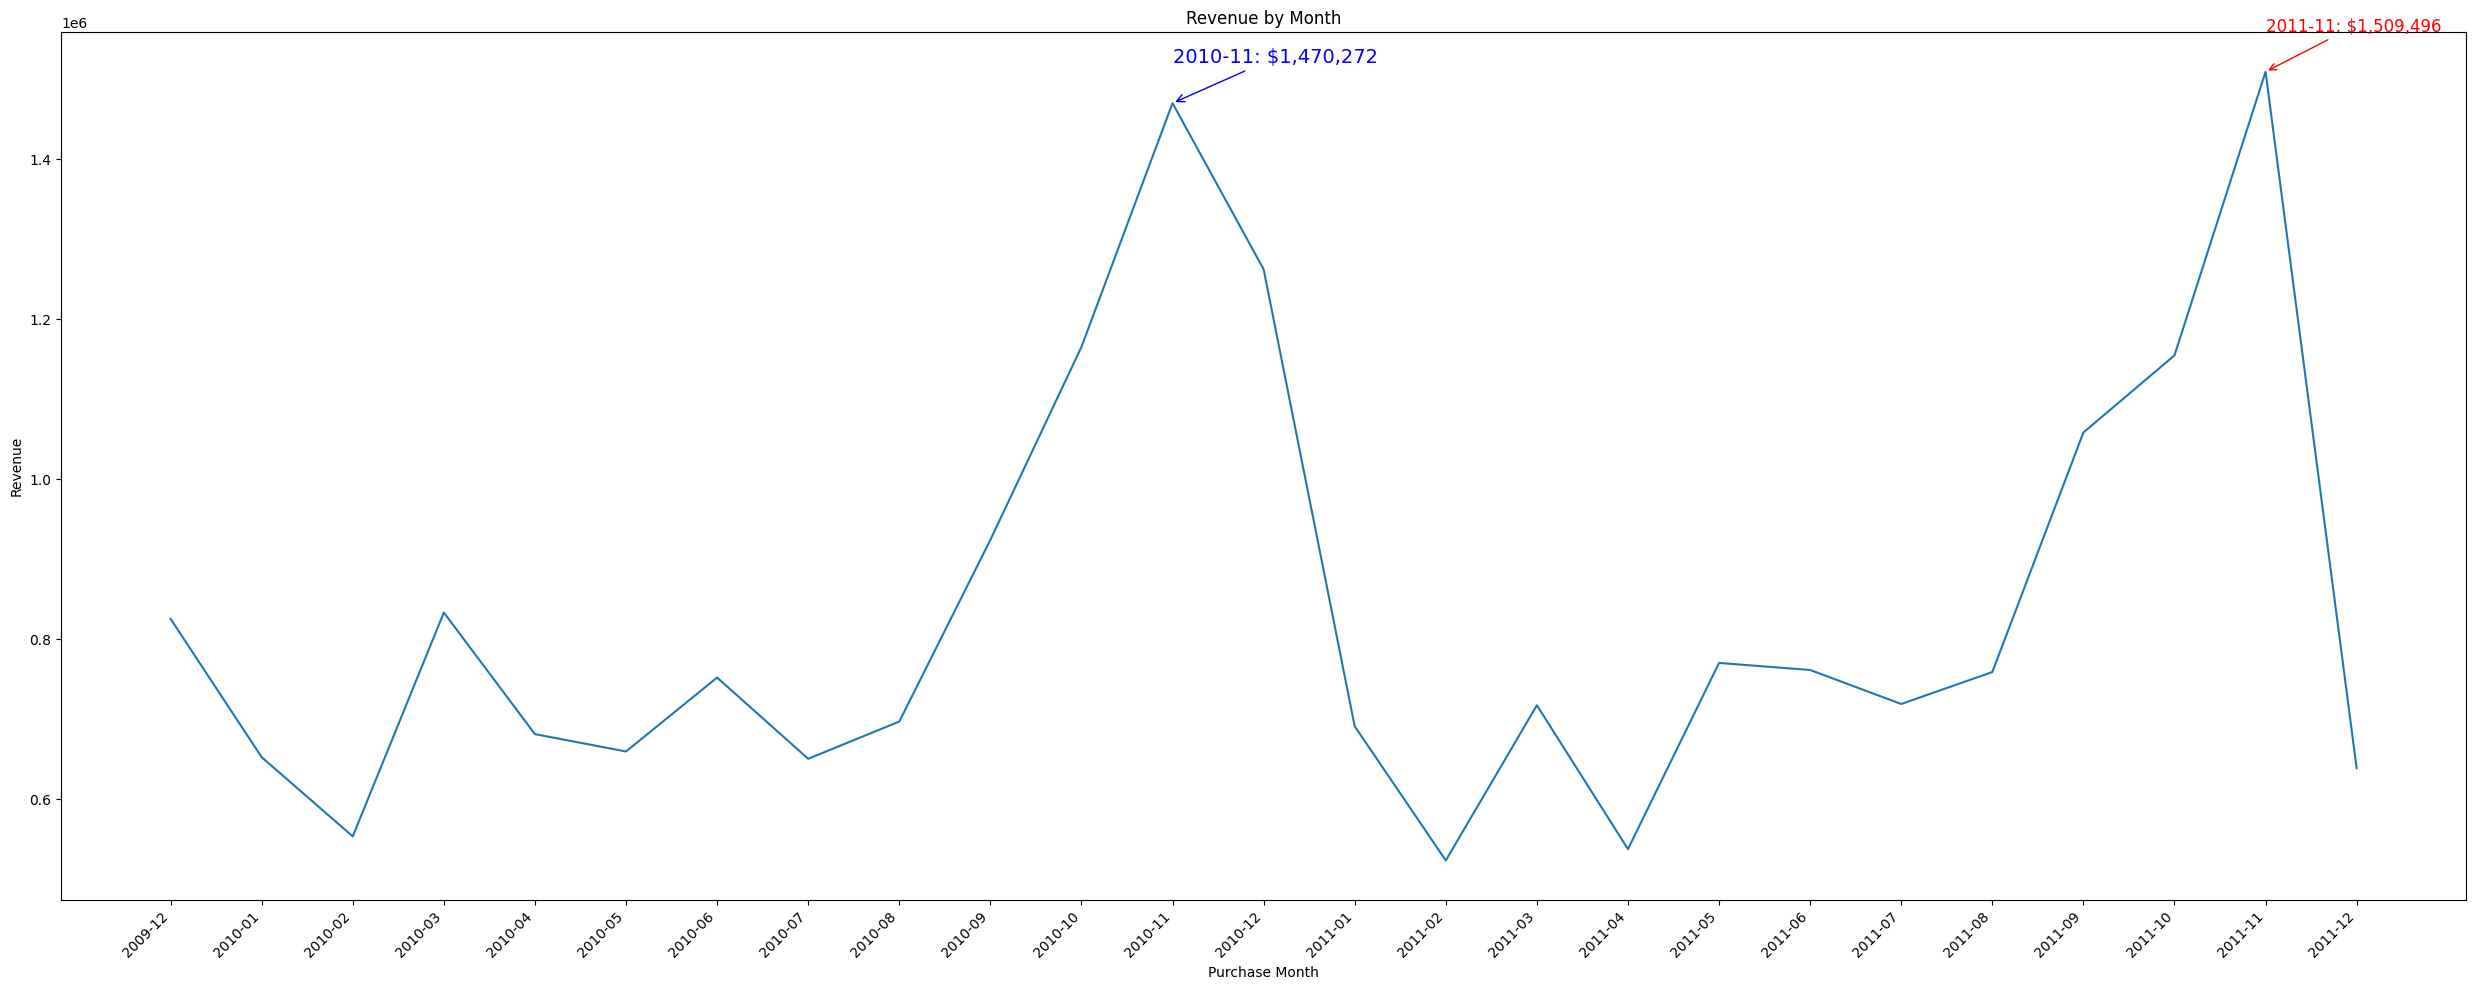

In [47]:
grouped = df.groupby('Purchase Month')['Revenue'].sum()

# Get the largest revenues to annotate on the graph
two_largest_revenues = grouped.nlargest(2)
highest_point = (grouped.idxmax(), two_largest_revenues.iloc[0])
highest_point_annotation = "November 2011: $1.5M"
second_highest_point = (two_largest_revenues.index[1], two_largest_revenues.iloc[1])
second_highest_point_annotation = "November 2010: $1.47M"

ax = grouped.plot(figsize=(25,10))

highest_x_pos = grouped.index.get_loc(highest_point[0])

ax.annotate(
    f"{highest_point[0]}: ${highest_point[1]:,.0f}",
    xy=(highest_x_pos, highest_point[1]),
    xytext=(highest_x_pos, highest_point[1] + 50000),
    arrowprops=dict(arrowstyle="->", color="red"),
    fontsize=12,
    color="red"
)

second_x_pos = grouped.index.get_loc(second_highest_point[0])

ax.annotate(
    f"{second_highest_point[0]}: ${second_highest_point[1]:,.0f}",
    xy=(second_x_pos, second_highest_point[1]),
    xytext=(second_x_pos, second_highest_point[1] + 50000), 
    arrowprops=dict(arrowstyle="->", color="blue"),
    fontsize=14,
    color="blue"
)

ax.set_xticks(range(len(grouped)))
ax.set_xticklabels(grouped.index, rotation=45, ha='right')
plt.title("Revenue by Month")
ax.set_xlabel('Purchase Month')
ax.set_ylabel('Revenue')
plt.tight_layout()
plt.savefig("Images/Revenue_by_month.png")

In [8]:
grouped.nlargest(7)

Purchase Month
2011-11    1509496.330
2010-11    1470272.482
2010-12    1262598.790
2010-10    1165483.910
2011-10    1154979.300
2011-09    1058590.172
2010-09     924333.011
Name: Revenue, dtype: float64

In [9]:
(grouped.nlargest(7).sum() + grouped['2011-12']) / grouped.sum() * 100

np.float64(43.79239321094896)

In [10]:
(grouped.nlargest(7).sum() + grouped['2011-11']) / (grouped.sum() + 900000) * 100

np.float64(45.97112866237377)

In [11]:
grouped.nsmallest(12)

Purchase Month
2011-02    523631.890
2011-04    537808.621
2010-02    553713.306
2011-12    638810.680
2010-07    650712.940
2010-01    652708.502
2010-05    659858.860
2010-04    681528.992
2011-01    691364.560
2010-08    697274.910
2011-03    717639.360
2011-07    719221.191
Name: Revenue, dtype: float64

As can be seen, sales are seasonal, and have a big boost around October, November, and December. If not for the fact that the data does not reach the end of December, December 2011 would be similarly boosted. The seven strongest months in terms of revenue are: September, October, November and December of 2010 and 2011 make up around 44% (46% if we assume a December performance similar to 2011) of total revenue, which would improve given full December 2011 data.

The weakest months are less consistent but it's centered around the post-holiday season in January through May.

Now to look at the trends by order volume and Average Order Value by month.

In [49]:
invoices_by_month = df.groupby('Purchase Month')['InvoiceDate'].count()

invoice_sum = df.groupby(['Purchase Month', 'Invoice'])['Revenue'].sum()
AOV = invoice_sum.groupby('Purchase Month').mean()

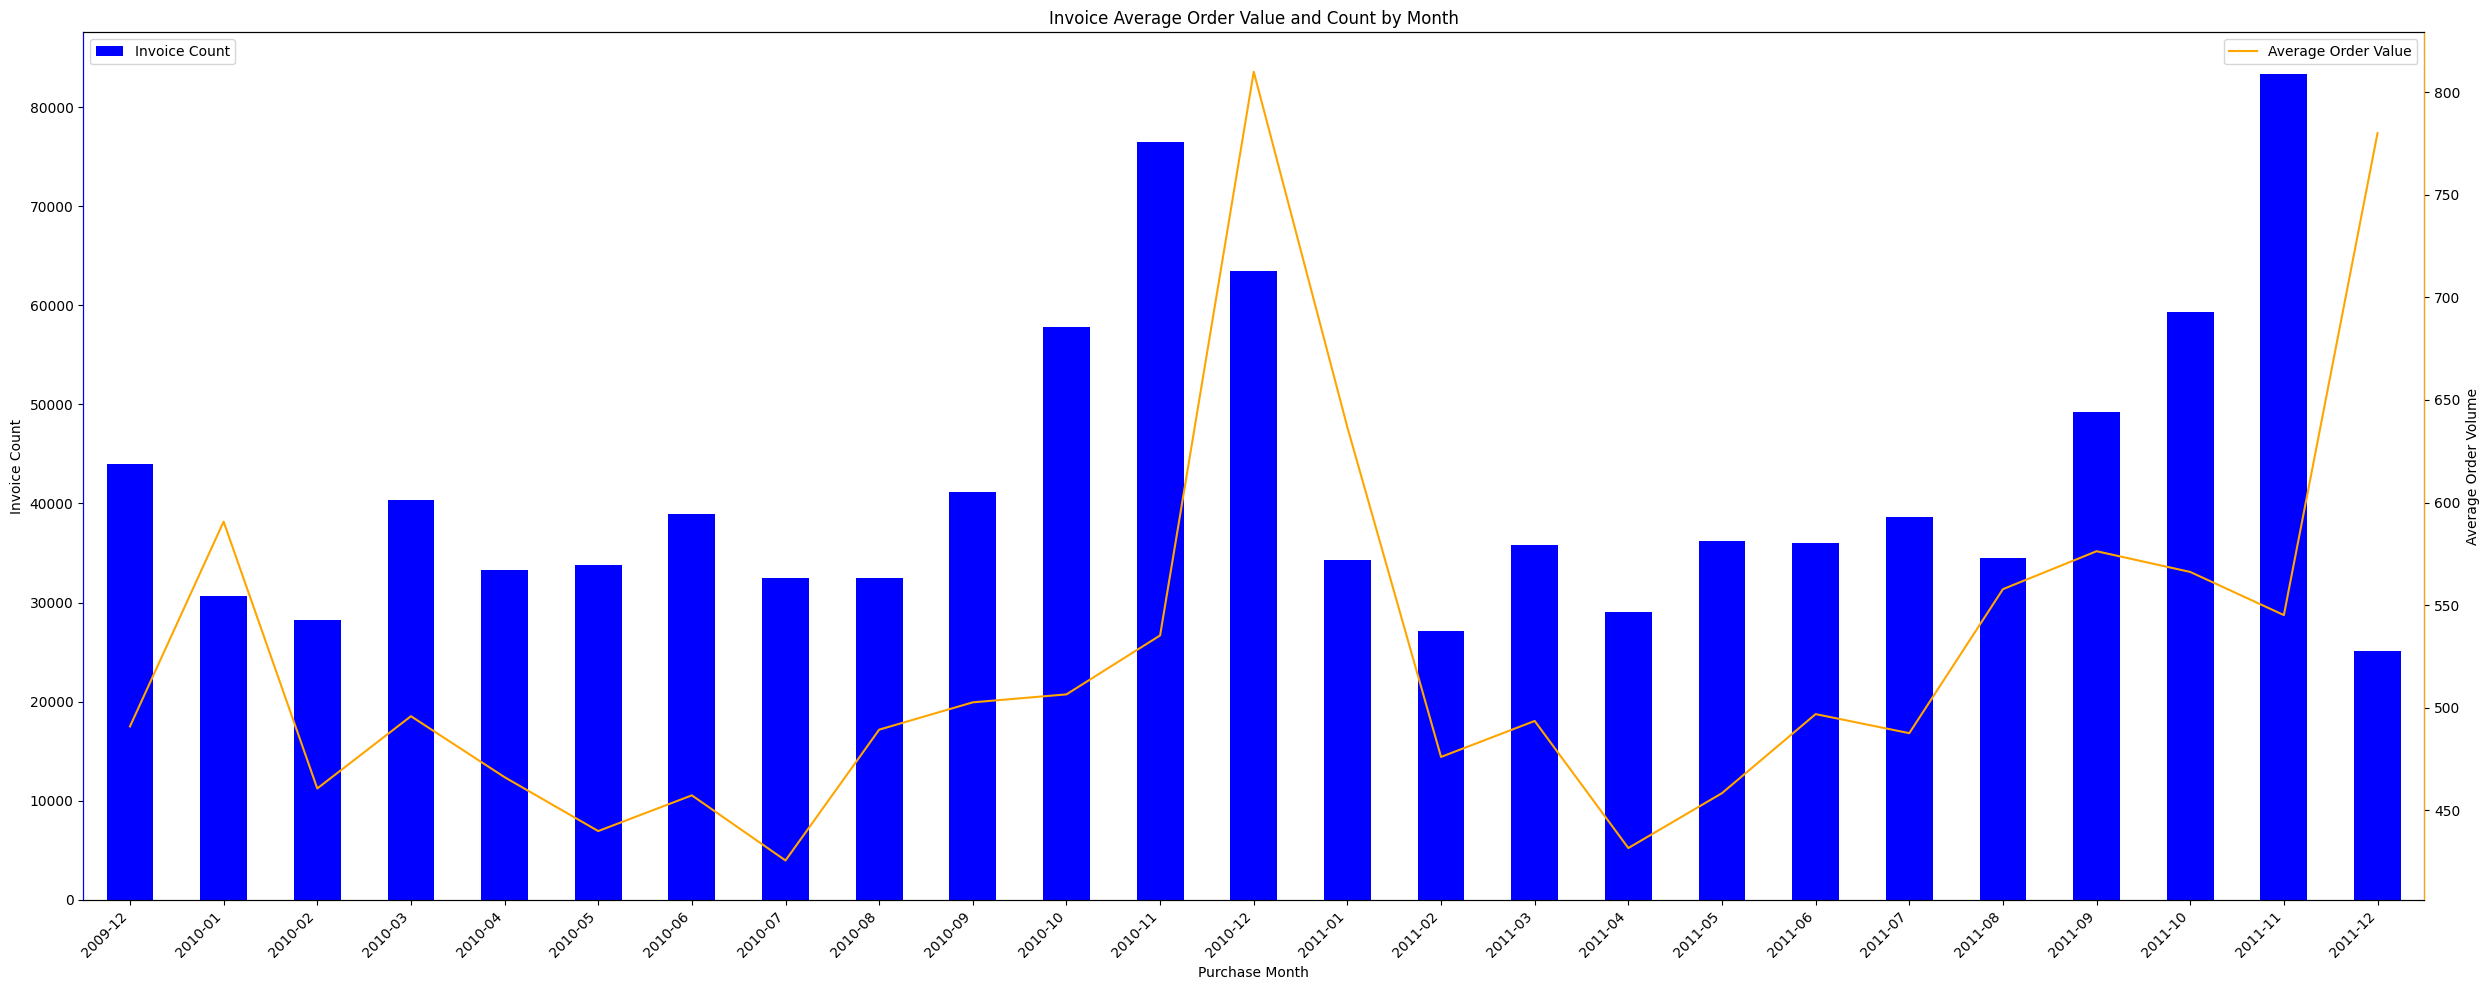

In [59]:
fig, ax1 = plt.subplots()
ax1 = invoices_by_month.plot.bar(figsize=(25,10), color='blue', label='Invoice Count')

ax2 = ax1.twinx()

ax2.plot(sorted(df['Purchase Month'].unique()), AOV.values, label="Average Order Value", color='orange')

ax1.set_xlabel('Purchase Month')
ax1.set_ylabel('Invoice Count')
ax2.set_ylabel('Average Order Volume')
ax2.spines['left'].set_color('blue')
ax2.spines['right'].set_color('orange')
ax1.legend(loc=2)
ax2.legend(loc=1)
ax1.set_xticks(range(len(grouped)))
ax1.set_xticklabels(grouped.index, rotation=45, ha='right')
plt.title("Invoice Average Order Value and Count by Month")
plt.tight_layout()
plt.savefig("Images/AOV_and_invoice_count_by_month.png")

The Average Order Valuea and Invoice Count are correlated with the periods og higher revenue. December 2012 was especially high in terms of Average Order Volume. Spring and Early Summer is the low point for AOV for the year, which likely has a lot of opportunity for promotions.

## RFM Analysis

RFM (Recency, Frequency, Monetary Value) Analysis is a way to segment customers to figure out which customers are the most valuable for the business.

Recency: How recently did they purchase?
Frequency: How often do they purchase?
Monetary Value: How much do they purchase?

This is a way

In [13]:
recency = df.groupby(by='Customer ID', as_index=False)['InvoiceDate'].max()
recency.columns = ['Customer ID', 'Last Purchase Date']
last_date = recency['Last Purchase Date'].max()
recency['Recency'] = recency['Last Purchase Date'].apply(lambda x: (last_date - x).days)

frequency = df.groupby(by='Customer ID', as_index=False)['InvoiceDate'].count()
frequency.columns = ['Customer ID', 'Frequency']

monetary_value = df.groupby(by='Customer ID', as_index=False)['Revenue'].sum()
monetary_value.columns = ['Customer ID', 'Monetary Value']

rf_df = recency.merge(frequency, on='Customer ID')
rfm_df = rf_df.merge(monetary_value, on='Customer ID').drop(columns='Last Purchase Date')

rfm_df['Recency Quintile'] = pd.qcut(x=rfm_df['Recency'], q=5, labels=[5,4,3,2,1]).astype(np.int64)
rfm_df['Frequency Quintile'] = pd.qcut(x=rfm_df['Frequency'], q=5, labels=[1,2,3,4,5]).astype(np.int64)
rfm_df['Monetary Value Quintile'] = pd.qcut(x=rfm_df['Monetary Value'], q=5, labels=[1,2,3,4,5]).astype(np.int64)

rfm_df['Mean RFM Score'] = ((rfm_df['Recency Quintile'] + rfm_df['Frequency Quintile'] + rfm_df['Monetary Value Quintile']) / 3).round(2)
rfm_df.drop(["Recency", "Frequency", "Monetary Value"], axis=1)


,Customer ID,Recency Quintile,Frequency Quintile,Monetary Value Quintile,Mean RFM Score
0,12346.0,2,2,5,3.00
1,12347.0,5,5,5,5.00
2,12348.0,3,3,4,3.33
3,12349.0,5,4,5,4.67
4,12350.0,2,2,2,2.00
...,...,...,...,...,...
5873,18283.0,5,5,4,4.67
5874,18284.0,1,2,2,1.67
5875,18285.0,1,1,2,1.33
5876,18286.0,1,3,4,2.67


The categories are arbitrarily chose. Top Customers could easily be >= 4.0 or == 5, for example.

In [14]:
rfm_df["Customer Segment"] = np.where(rfm_df['Mean RFM Score'] >= 4.5, "Top Customers",
                                np.where(rfm_df['Mean RFM Score'] >= 4, "High Value Customers",
                                    np.where(rfm_df['Mean RFM Score'] >= 3, "Medium Value Customers",
                                        np.where(rfm_df['Mean RFM Score'] >= 2, 'Low Value Customers','Lost Customers'))))

In [15]:
top_customer_df = pd.merge(df, rfm_df[rfm_df['Customer Segment'] == "Top Customers"], how='inner')
high_value_customer_df = pd.merge(df, rfm_df[rfm_df['Customer Segment'] == "High Value Customers"], how='inner')
medium_value_customer_df = pd.merge(df, rfm_df[rfm_df['Customer Segment'] == "Medium Value Customers"], how='inner')
low_value_customer_df = pd.merge(df, rfm_df[rfm_df['Customer Segment'] == "Low Value Customers"], how='inner')
lost_customer_df = pd.merge(df, rfm_df[rfm_df['Customer Segment'] == "Lost Customers"], how='inner')


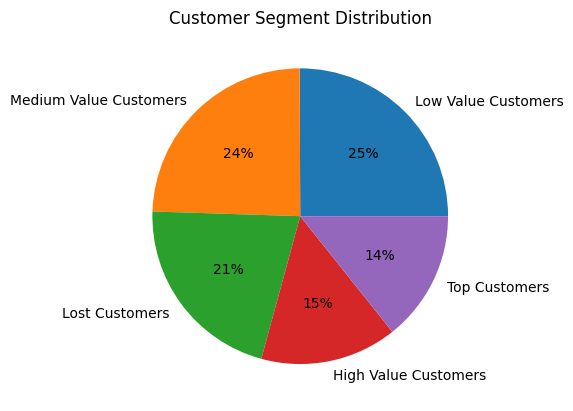

In [52]:
plt.pie(rfm_df["Customer Segment"].value_counts(), labels = rfm_df["Customer Segment"].value_counts().index,autopct='%.0f%%')
plt.title("Customer Segment Distribution")
plt.savefig('Images/CustomerSegments.png')

There is a fairly large amount of high value and top customers in this dataset. 14% for the top and 15% for the tier below it is a good sign for the business.

I want to look at the most common items purchased, and then the most valuable products by revenue generated to spot any sort of trends, e.g. high value customers purchasing more of a specific type of item. 

Without being able to find trends by category of item, it may be difficult to find any strong trends. However, this probably needs some discussion with the product or marketing team to make sure the categories are consistent among the teams.

In [16]:
top_customer_df['Description'].value_counts().head(50)

Description
WHITE HANGING HEART T-LIGHT HOLDER     2639
REGENCY CAKESTAND 3 TIER               1852
JUMBO BAG RED RETROSPOT                1753
ASSORTED COLOUR BIRD ORNAMENT          1450
LUNCH BAG  BLACK SKULL.                1351
PARTY BUNTING                          1169
JUMBO STORAGE BAG SUKI                 1168
LUNCH BAG CARS BLUE                    1165
LUNCH BAG SPACEBOY DESIGN              1161
LUNCH BAG RED RETROSPOT                1137
JUMBO SHOPPER VINTAGE RED PAISLEY      1128
LUNCH BAG WOODLAND                     1104
HOME BUILDING BLOCK WORD               1085
STRAWBERRY CERAMIC TRINKET BOX         1041
60 TEATIME FAIRY CAKE CASES            1040
WOODEN FRAME ANTIQUE WHITE             1039
WOODEN PICTURE FRAME WHITE FINISH       997
PAPER CHAIN KIT 50'S CHRISTMAS          993
JUMBO BAG STRAWBERRY                    993
POSTAGE                                 978
HEART OF WICKER SMALL                   968
REX CASH+CARRY JUMBO SHOPPER            939
PACK OF 60 PINK PAIS

In [17]:
high_value_customer_df['Description'].value_counts().head(50)

Description
WHITE HANGING HEART T-LIGHT HOLDER    1182
REGENCY CAKESTAND 3 TIER               745
ASSORTED COLOUR BIRD ORNAMENT          625
REX CASH+CARRY JUMBO SHOPPER           545
JUMBO BAG RED RETROSPOT                514
WOODEN FRAME ANTIQUE WHITE             470
WOODEN PICTURE FRAME WHITE FINISH      460
PARTY BUNTING                          448
HEART OF WICKER SMALL                  438
LUNCH BAG SPACEBOY DESIGN              424
HEART OF WICKER LARGE                  415
60 TEATIME FAIRY CAKE CASES            400
RED HANGING HEART T-LIGHT HOLDER       397
HOME BUILDING BLOCK WORD               397
PAPER CHAIN KIT 50'S CHRISTMAS         396
LUNCH BAG  BLACK SKULL.                386
NATURAL SLATE HEART CHALKBOARD         375
LOVE BUILDING BLOCK WORD               367
STRAWBERRY CERAMIC TRINKET BOX         364
BAKING SET 9 PIECE RETROSPOT           360
LUNCH BAG CARS BLUE                    360
CHOCOLATE HOT WATER BOTTLE             351
PLEASE ONE PERSON METAL SIGN           343

In [18]:
medium_value_customer_df['Description'].value_counts().head(50)

Description
WHITE HANGING HEART T-LIGHT HOLDER     838
REGENCY CAKESTAND 3 TIER               500
ASSORTED COLOUR BIRD ORNAMENT          445
BAKING SET 9 PIECE RETROSPOT           382
REX CASH+CARRY JUMBO SHOPPER           357
HEART OF WICKER LARGE                  344
PARTY BUNTING                          321
PAPER CHAIN KIT 50'S CHRISTMAS         318
STRAWBERRY CERAMIC TRINKET BOX         315
NATURAL SLATE HEART CHALKBOARD         313
HEART OF WICKER SMALL                  311
POSTAGE                                299
JUMBO BAG RED RETROSPOT                296
VINTAGE SNAP CARDS                     290
HOME BUILDING BLOCK WORD               281
60 TEATIME FAIRY CAKE CASES            278
SCOTTIE DOG HOT WATER BOTTLE           266
LOVE BUILDING BLOCK WORD               259
LUNCH BAG  BLACK SKULL.                253
RED HANGING HEART T-LIGHT HOLDER       244
LUNCH BAG SPACEBOY DESIGN              241
CHOCOLATE HOT WATER BOTTLE             239
PACK OF 60 PINK PAISLEY CAKE CASES     234

In [19]:
low_value_customer_df['Description'].value_counts().head(50)

Description
WHITE HANGING HEART T-LIGHT HOLDER     357
REGENCY CAKESTAND 3 TIER               257
REX CASH+CARRY JUMBO SHOPPER           215
BAKING SET 9 PIECE RETROSPOT           206
ASSORTED COLOUR BIRD ORNAMENT          196
POSTAGE                                171
STRAWBERRY CERAMIC TRINKET BOX         158
NATURAL SLATE HEART CHALKBOARD         138
HEART OF WICKER SMALL                  137
HEART OF WICKER LARGE                  134
RED HANGING HEART T-LIGHT HOLDER       128
PARTY BUNTING                          126
VINTAGE SNAP CARDS                     125
PAPER CHAIN KIT 50'S CHRISTMAS         122
LOVE BUILDING BLOCK WORD               121
HOME BUILDING BLOCK WORD               121
60 TEATIME FAIRY CAKE CASES            120
FELTCRAFT 6 FLOWER FRIENDS             106
JUMBO BAG RED RETROSPOT                105
PACK OF 60 PINK PAISLEY CAKE CASES     103
WOODEN FRAME ANTIQUE WHITE             103
VICTORIAN GLASS HANGING T-LIGHT        103
SWEETHEART CERAMIC TRINKET BOX         102

In [20]:
lost_customer_df['Description'].value_counts().head(50)

Description
WHITE HANGING HEART T-LIGHT HOLDER     165
REX CASH+CARRY JUMBO SHOPPER            85
BAKING SET 9 PIECE RETROSPOT            84
REGENCY CAKESTAND 3 TIER                74
ASSORTED COLOUR BIRD ORNAMENT           61
PARTY BUNTING                           57
POSTAGE                                 55
GRAND CHOCOLATECANDLE                   51
HEART OF WICKER LARGE                   48
ANTIQUE SILVER TEA GLASS ETCHED         46
HOME BUILDING BLOCK WORD                45
HEART OF WICKER SMALL                   45
EDWARDIAN PARASOL NATURAL               44
STRAWBERRY CERAMIC TRINKET BOX          44
RED HANGING HEART T-LIGHT HOLDER        44
WHITE WOOD GARDEN PLANT LADDER          44
VINTAGE SNAP CARDS                      42
WOODEN FRAME ANTIQUE WHITE              42
60 TEATIME FAIRY CAKE CASES             42
RETRO SPOT TEA SET CERAMIC 11 PC        41
PACK OF 72 RETRO SPOT CAKE CASES        40
PACK OF 60 PINK PAISLEY CAKE CASES      39
SCOTTIE DOG HOT WATER BOTTLE            38

Not much to really see besides the low volume customers have some interesting random itesm in the top 10, like Hearts of Wicker and some Antique Silver Tea Glass Etched items.

In [21]:
top_customer_df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(50)

Description
REGENCY CAKESTAND 3 TIER               206022.00
WHITE HANGING HEART T-LIGHT HOLDER     154872.47
JUMBO BAG RED RETROSPOT                 95457.88
ASSORTED COLOUR BIRD ORNAMENT           88706.36
POSTAGE                                 75804.35
Manual                                  68992.26
PARTY BUNTING                           62831.28
WOOD BLACK BOARD ANT WHITE FINISH       51589.49
BLACK RECORD COVER FRAME                51099.77
ROTATING SILVER ANGELS T-LIGHT HLDR     48610.42
CHILLI LIGHTS                           47571.65
JUMBO BAG STRAWBERRY                    45736.69
VINTAGE UNION JACK MEMOBOARD            45702.87
PAPER CHAIN KIT 50'S CHRISTMAS          42376.63
CREAM HEART CARD HOLDER                 40674.41
RABBIT NIGHT LIGHT                      37294.57
JUMBO BAG PINK POLKADOT                 36065.74
JUMBO  BAG BAROQUE BLACK WHITE          36022.62
HEART OF WICKER LARGE                   34712.28
EDWARDIAN PARASOL NATURAL               34401.41
RED TOAD

In [22]:
high_value_customer_df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(50)

Description
WHITE HANGING HEART T-LIGHT HOLDER    44084.34
REGENCY CAKESTAND 3 TIER              43460.85
JUMBO BAG RED RETROSPOT               25020.53
POSTAGE                               22113.90
ASSORTED COLOUR BIRD ORNAMENT         19472.16
PARTY BUNTING                         18860.90
PAPER CHAIN KIT 50'S CHRISTMAS        17268.20
Manual                                16050.73
RED  HARMONICA IN BOX                 12607.85
JUMBO BAG STRAWBERRY                  11595.94
VINTAGE UNION JACK BUNTING            11347.50
RABBIT NIGHT LIGHT                    10496.91
ALARM CLOCK BAKELIKE RED               9859.50
RED HANGING HEART T-LIGHT HOLDER       9535.45
CHOCOLATE HOT WATER BOTTLE             9279.45
PINK PAPER PARASOL                     9031.20
WOOD S/3 CABINET ANT WHITE FINISH      8921.60
JUMBO BAG PINK VINTAGE PAISLEY         8527.70
JUMBO  BAG BAROQUE BLACK WHITE         8295.10
WOODEN FRAME ANTIQUE WHITE             8288.60
CHILLI LIGHTS                          8265.25
V

In [23]:
medium_value_customer_df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(50)

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
MEDIUM CERAMIC TOP STORAGE JAR         77559.85
PICNIC BASKET WICKER 60 PIECES         39619.50
WHITE HANGING HEART T-LIGHT HOLDER     26991.05
Manual                                 22228.60
REGENCY CAKESTAND 3 TIER               20394.10
POSTAGE                                17786.89
PARTY BUNTING                          16102.90
PAPER CHAIN KIT 50'S CHRISTMAS         15723.10
CHILLI LIGHTS                          13776.99
RED  HARMONICA IN BOX                  12917.07
SET/4 WHITE RETRO STORAGE CUBES        12652.20
ASSORTED COLOUR BIRD ORNAMENT          12617.58
JUMBO BAG RED RETROSPOT                12108.23
ROUND SNACK BOXES SET OF 4 FRUITS       9439.90
BAKING SET 9 PIECE RETROSPOT            8658.15
NATURAL SLATE HEART CHALKBOARD          8529.50
EDWARDIAN PARASOL NATURAL               8486.20
SMALL CHINESE STYLE SCISSOR             8468.14
CERAMIC CAKE STAND + HANGING CAKES      8408.60
PINK HAPPY BIRTHDAY BUNTING 

In [24]:
low_value_customer_df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(50)

Description
Manual                                 40467.82
WHITE HANGING HEART T-LIGHT HOLDER     21813.40
FAIRY CAKE FLANNEL ASSORTED COLOUR     15071.55
REGENCY CAKESTAND 3 TIER               14114.10
DOORMAT FAIRY CAKE                      9311.15
SET/4 WHITE RETRO STORAGE CUBES         8912.45
POSTAGE                                 8401.95
GIN + TONIC DIET METAL SIGN             8262.15
TEA TIME TEA TOWELS                     6458.00
VINTAGE UNION JACK BUNTING              5421.00
LUNCH BAG  BLACK SKULL.                 5121.50
LUNCH BAG CARS BLUE                     4722.40
ASSORTED COLOUR BIRD ORNAMENT           4679.33
ASSORTED COLOURS SILK FAN               4594.44
LUNCH BAG WOODLAND                      4518.00
PARTY BUNTING                           4089.60
AFGHAN SLIPPER SOCK PAIR                3871.15
PAPER CHAIN KIT 50'S CHRISTMAS          3853.00
JUMBO BAG RED RETROSPOT                 3572.46
BAKING SET 9 PIECE RETROSPOT            3497.70
PAPER CHAIN KIT EMPIRE      

In [25]:
lost_customer_df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(50)

Description
Manual                                4601.16
WHITE HANGING HEART T-LIGHT HOLDER    4311.20
REGENCY CAKESTAND 3 TIER              2495.25
POSTAGE                               2455.95
ANTIQUE SILVER TEA GLASS ENGRAVED     2074.27
PARTY BUNTING                         1995.55
EDWARDIAN PARASOL NATURAL             1896.55
GRAND CHOCOLATECANDLE                 1841.05
ASSORTED COLOUR BIRD ORNAMENT         1598.74
BAKING SET 9 PIECE RETROSPOT          1547.40
HANGING JAM JAR T-LIGHT HOLDER        1542.44
COLOUR GLASS. STAR T-LIGHT HOLDER     1529.25
ANTIQUE SILVER TEA GLASS ETCHED       1421.74
STRAWBERRY CERAMIC TRINKET BOX        1202.99
VINTAGE UNION JACK BUNTING            1156.00
JUMBO  BAG BAROQUE BLACK WHITE        1135.95
SET/4 WHITE RETRO STORAGE CUBES       1078.60
BLACK RECORD COVER FRAME              1024.74
CREAM SWEETHEART MINI CHEST            981.75
LARGE HANGING GLASS+ZINC LANTERN       896.00
HOME BUILDING BLOCK WORD               892.50
HEART OF WICKER LARGE 

All five of the segments seem to have the top products, though in different orders.

### Revenue by Customer Segment

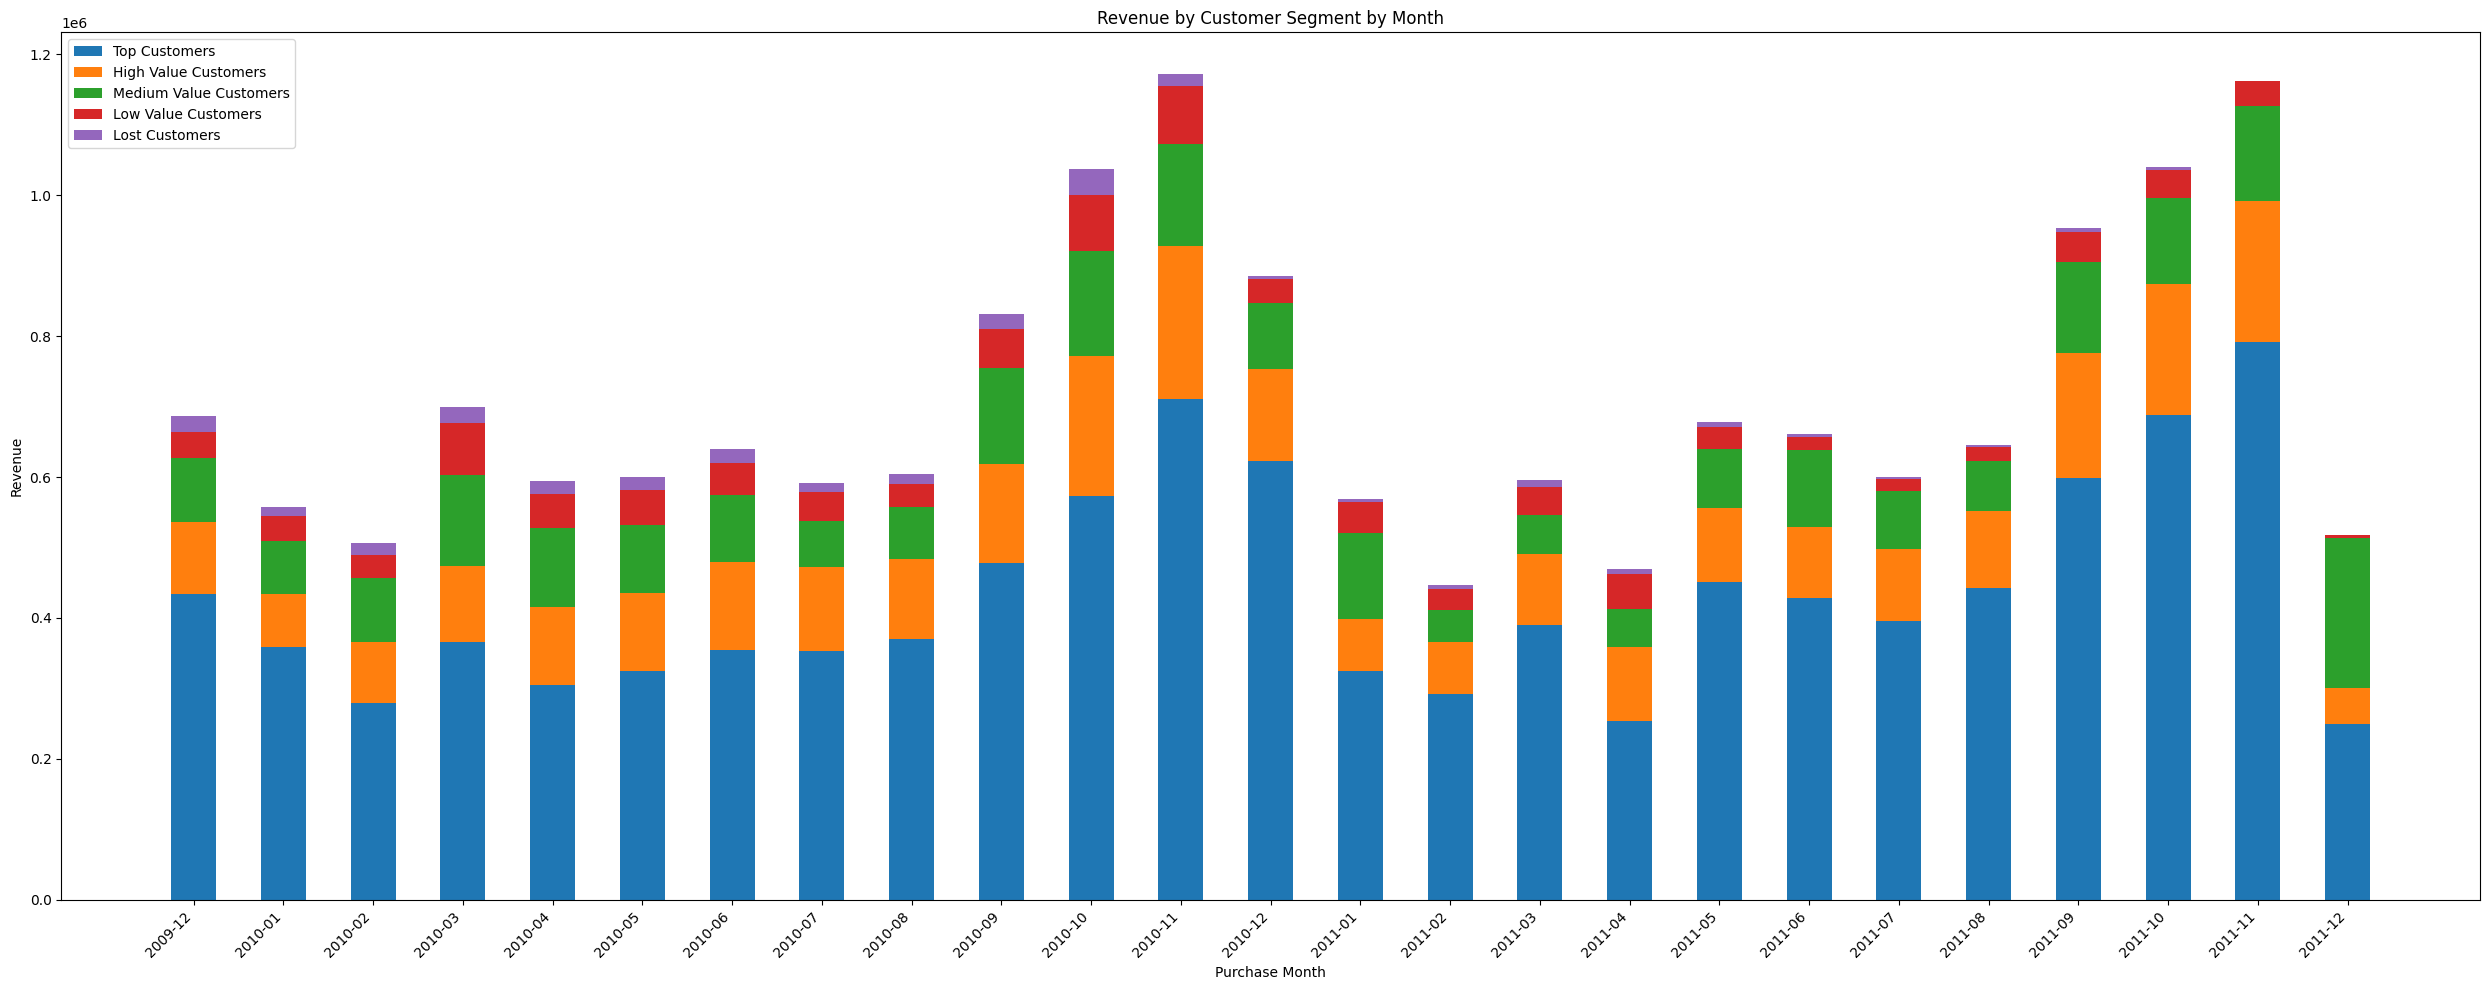

In [60]:
top_customers_by_month = top_customer_df.groupby('Purchase Month')['Revenue'].sum()
high_value_customers_by_month = high_value_customer_df.groupby('Purchase Month')['Revenue'].sum()
medium_value_customers_by_month = medium_value_customer_df.groupby('Purchase Month')['Revenue'].sum()
low_value_customers_by_month = low_value_customer_df.groupby('Purchase Month')['Revenue'].sum()
lost_customers_by_month = lost_customer_df.groupby('Purchase Month')['Revenue'].sum()

all_months = sorted(df['Purchase Month'].unique())

top_customers_by_month = top_customers_by_month.reindex(all_months, fill_value=0)
high_value_customers_by_month = high_value_customers_by_month.reindex(all_months, fill_value=0)
medium_value_customers_by_month = medium_value_customers_by_month.reindex(all_months, fill_value=0)
low_value_customers_by_month = low_value_customers_by_month.reindex(all_months, fill_value=0)
lost_customers_by_month = lost_customers_by_month.reindex(all_months, fill_value=0)

customer_segment_data = {
    "Top Customers": top_customers_by_month,
    "High Value Customers": high_value_customers_by_month,
    "Medium Value Customers": medium_value_customers_by_month,
    "Low Value Customers": low_value_customers_by_month,
    "Lost Customers": lost_customers_by_month,  # Fixed typo: Custoemrs -> Customers
}

plt.figure(figsize=(25,10))
ax = plt.subplot()
bottom = np.zeros(len(all_months))
width = 0.5

for customer_segment, revenue_data in customer_segment_data.items():
    p = ax.bar(all_months, revenue_data.values, width, label=customer_segment, bottom=bottom)
    bottom += revenue_data.values

ax.set_xlabel('Purchase Month')
ax.set_ylabel('Revenue')
ax.set_title('Revenue by Customer Segment by Month')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("Images/Revenue_by_customer_segment_by_month.png")

In [27]:
((grouped / df.groupby('Purchase Month')['Revenue'].sum()) * 100).sort_values(ascending=False)


Purchase Month
2011-10    59.521836
2011-05    58.543955
2011-08    58.373705
2011-09    56.531183
2011-06    56.314968
2011-02    55.905443
2010-01    55.059334
2011-07    54.926342
2011-03    54.385242
2010-07    54.218773
2010-08    53.015966
2009-12    52.603836
2011-11    52.400602
2010-09    51.754212
2010-02    50.409544
2010-05    49.303994
2010-12    49.267452
2010-10    49.110135
2010-11    48.321455
2010-06    47.223987
2011-04    47.185878
2011-01    47.065881
2010-04    44.838552
2010-03    43.879129
2011-12    39.162814
Name: Revenue, dtype: float64

In [28]:
((high_value_customers_by_month / df.groupby('Purchase Month')['Revenue'].sum()) * 100).sort_values(ascending=False)

Purchase Month
2011-04    19.584251
2010-07    18.432011
2010-10    17.127151
2011-09    16.838055
2010-05    16.724589
2010-06    16.533908
2010-08    16.429960
2011-10    16.183349
2010-04    16.058984
2010-02    15.780459
2010-09    15.197153
2010-11    14.793525
2011-08    14.314615
2011-07    14.264678
2011-02    14.043975
2011-03    13.962806
2011-05    13.601429
2011-11    13.298387
2011-06    13.196230
2010-03    12.920304
2009-12    12.335372
2010-01    11.408105
2011-01    10.595448
2010-12    10.392999
2011-12     8.006601
Name: Revenue, dtype: float64

Around 50% of revenue is generated by the top customers for the brand, with a high of 59.5% in October 2011 and a low of ~44% in March 2010 (39% in December 2012 which is incomplete). Their spending is not particularly seasonal, unlike general revenue trends. The top customers have their highest share in slow and strong months as well as low shares in slow and strong months as well.

## Cohort Analysis

I need to set up the Cohort Analysis by creating a column for the first month of purchase, frequency of purchasing, and spending per order.

For the first month of purchase, I'll need to manipulate the dates so I can grab just the year and month (to be stored as 'Invoice Month') since they also include the day and time. Then, I will have to find the earliest month of purchase based on the months/years that will be stored as 'Cohort Month'. From there I will create an index for each cohort based on how many months it has been since their first purchase. 

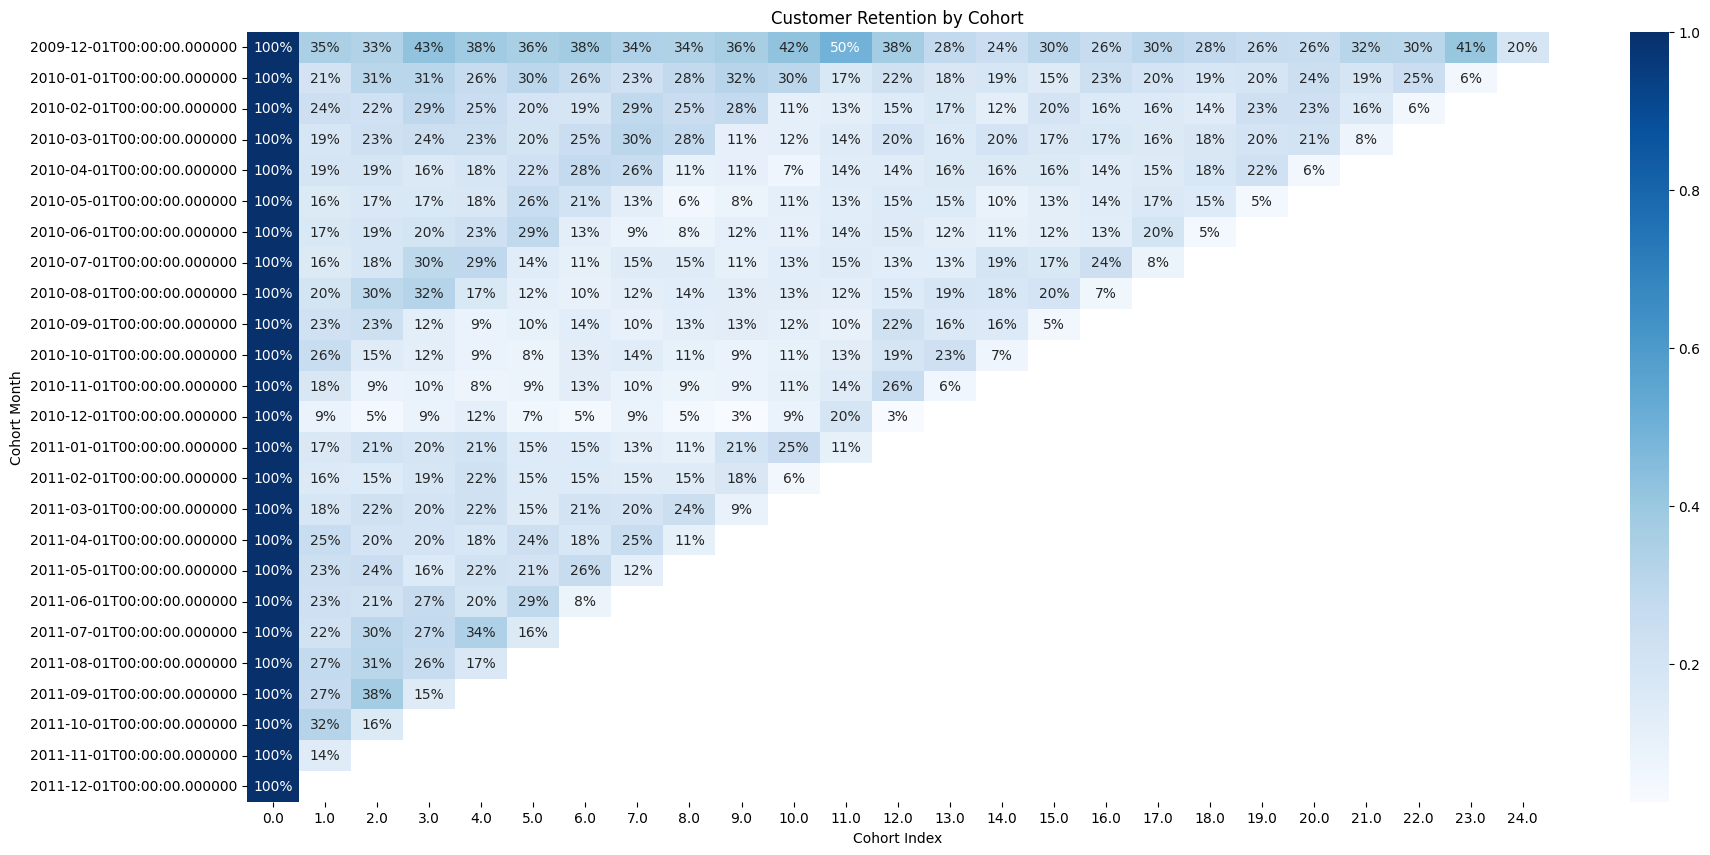

In [29]:
def get_month(date):
    # grabs the month and year for all of a month's invoices to be consolidated into the first day of the month
    return dt.datetime(date.year, date.month, 1)

df['Invoice Month'] = df['InvoiceDate'].apply(get_month)
df['Cohort Month'] = df.groupby('Customer ID')['Invoice Month'].transform('min')

def adjust_months(days):
    # Arbitrarily decides if the days are close enough to be rounded up to the next month
    # 30 is arbitrarily chose to be a month (there is not real objective month timeframe), and 20 is also arbitrarily chosen because it's close-ish to 30.
    # 20 can really be any number
    months, remainder = divmod(days,30)
    if remainder >= 20:
        return months + 1
    else:
        return months
    
def get_time_delta(df, column1, column2):
    # After a simple subtraction, use adjust_months to determine if the remainder is close enough to a full month to round
    days = (df[column1] - df[column2]).dt.days
    adjusted_months = days.map(adjust_months)
    return adjusted_months

adjusted_months = get_time_delta(df, 'Invoice Month', 'Cohort Month')
df['Cohort Index'] = adjusted_months

#Cohort Heat map
cohort_data = df[df['Quantity'] > 0].groupby(['Cohort Month','Cohort Index'])['Customer ID'].apply(pd.Series.nunique).reset_index()
cohort_table = cohort_data.pivot(index='Cohort Month', columns=['Cohort Index'],values='Customer ID')
cohort_table = cohort_table.divide(cohort_table.iloc[:,0], axis=0)
plt.figure(figsize=(21,10))
sns.heatmap(cohort_table,annot=True,fmt='.0%', cmap='Blues')
plt.title("Customer Retention by Cohort")
plt.savefig('Images/CohortAnalysis.png')

There are some interesting points:
* The first cohort is especially consistent.
* There is a strange parallelogram with a base at the 2010-12-01 00:00:00 cohort where there is a noticeable decrease in consistency (between 0 and 20%), which the cohorts eventually recovered from to get to the 20-30% retention rate that is more typical for other cohorts. Even weirder, the cohorts after do not even seem to have this effect at all.
* The last entry is lower than expected because the data does not extend to December 31st, and in fact ends on December 9th. So, the values are expected to be around three times higher.

Some things to do:
* Look at the 2009-12-01 00:00:00 and 2010-12-01 00:00:00 cohorts to see if there is anything strange about it. The former is especially loyal, and the latter is especially sporadic.
* Look into the downturn in activity by older cohorts from January to October 2011.

## Downturn from January to October 2011 for previous customers
The "Parallelogram", the period of low activity for previous customers, is interesting because it does not extend to future clients which means it likely isn't economic conditions. This includes the well scoring cohorts from the start of 2010, though the quality of the cohorts was generally decreasing until February 2011.

I want to look at a few things during this time period:
* I wanted to compare revenue, invoice count, and average order value during these two time periods.

In [ ]:
downturn_cohorts = df['Cohort Month'].unique()[3:13]
post_downturn_cohorts = df['Cohort Month'].unique()[13:]
downturn_dates = df['Invoice Month'].unique()[3:13]

In [66]:
downturn_cohorts_df = df[df['Cohort Month'].isin(downturn_cohorts)]
downturn_cohorts_df = downturn_cohorts_df[downturn_cohorts_df['Invoice Month'].isin(downturn_dates)]
post_downturn_cohorts_df = df[df['Cohort Month'].isin(post_downturn_cohorts)]
post_downturn_cohorts_df = post_downturn_cohorts_df[post_downturn_cohorts_df['Invoice Month'].isin(downturn_dates)]

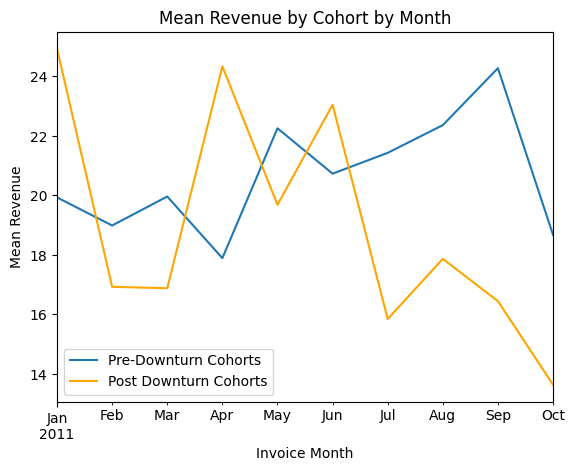

In [84]:
downturn_cohorts_df.groupby('Invoice Month')['Revenue'].mean().plot(label='Pre-Downturn Cohorts')
post_downturn_cohorts_df.groupby('Invoice Month')['Revenue'].mean().plot(color='orange', label='Post Downturn Cohorts')
plt.ylabel('Mean Revenue')
plt.title("Mean Revenue by Cohort by Month")
plt.legend()


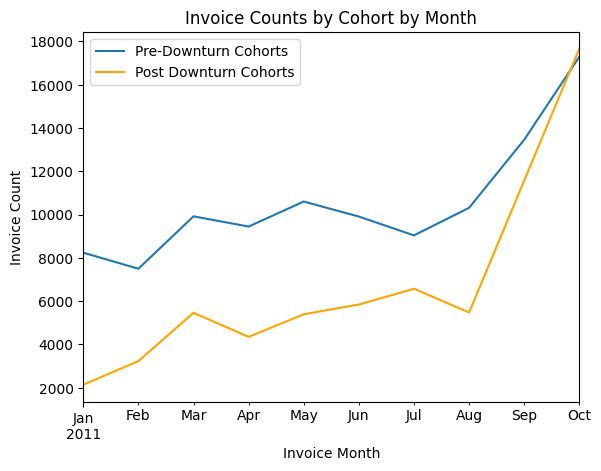

In [85]:
downturn_cohorts_df.groupby('Invoice Month')['Invoice'].count().plot(label='Pre-Downturn Cohorts')
post_downturn_cohorts_df.groupby('Invoice Month')['Invoice'].count().plot(color='orange', label='Post Downturn Cohorts')
plt.ylabel('Invoice Count')
plt.title("Invoice Counts by Cohort by Month")
plt.legend()

Not much can be gathered from this unfortunately, however it is an important thing to look into to see if the mistake or situation can be avoided.

## Conclusion

Revenue is concentrated at the end of the year, and also concentrated within the top 14% of customers.

Revenue is low in the spring and summer.